In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
import re

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import seaborn as sns
import matplotlib.pyplot as plt
import warnings

In [2]:
# loading the dataset into the dataframe pandas
data=pd.read_csv("Language Detection.csv")
data

,Text,Language
0,"Nature, in the broadest sense, is the natural...",English
1,"""Nature"" can refer to the phenomena of the phy...",English
2,"The study of nature is a large, if not the onl...",English
3,"Although humans are part of nature, human acti...",English
4,[1] The word nature is borrowed from the Old F...,English
...,...,...
10332,ನಿಮ್ಮ ತಪ್ಪು ಏನು ಬಂದಿದೆಯೆಂದರೆ ಆ ದಿನದಿಂದ ನಿಮಗೆ ಒ...,Kannada
10333,ನಾರ್ಸಿಸಾ ತಾನು ಮೊದಲಿಗೆ ಹೆಣಗಾಡುತ್ತಿದ್ದ ಮಾರ್ಗಗಳನ್...,Kannada
10334,ಹೇಗೆ ' ನಾರ್ಸಿಸಿಸಮ್ ಈಗ ಮರಿಯನ್ ಅವರಿಗೆ ಸಂಭವಿಸಿದ ಎ...,Kannada
10335,ಅವಳು ಈಗ ಹೆಚ್ಚು ಚಿನ್ನದ ಬ್ರೆಡ್ ಬಯಸುವುದಿಲ್ಲ ಎಂದು ...,Kannada


In [3]:
# checking null values
data.isnull().sum()

Text        0
Language    0
dtype: int64

In [4]:
# checking for different target labels
data["Language"].value_counts()

English       1385
French        1014
Spanish        819
Portugeese     739
Italian        698
Russian        692
Sweedish       676
Malayalam      594
Dutch          546
Arabic         536
Turkish        474
German         470
Tamil          469
Danish         428
Kannada        369
Greek          365
Hindi           63
Name: Language, dtype: int64

In [5]:
# split data into train and test set 
X = data["Text"]
y = data["Language"]

In [6]:
# from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)

In [7]:
# creating a list for appending the preprocessed text
# import re
data_list = []
# iterating through all the text
for text in X:
       # removing the symbols and numbers
        text = re.sub(r'[!@#$(),n"%^*?:;~`0-9]', ' ', text)
        text = re.sub(r'[[]]', ' ', text)
        # converting the text to lower case
        text = text.lower()
        # appending to data_list
        data_list.append(text)

/var/folders/nr/vw6x134n6n922pgr8m9nr9t80000gn/T/ipykernel_2083/2388344349.py:8: FutureWarning: Possible nested set at position 1
  text = re.sub(r'[[]]', ' ', text)


In [8]:
# from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer()
X = cv.fit_transform(data_list).toarray()
X.shape

(10337, 34937)

In [9]:
# from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size = 0.20)

In [10]:
# from sklearn.naive_bayes import MultinomialNB
model = MultinomialNB()
model.fit(x_train, y_train)

MultinomialNB()

In [11]:
# Prediction 
y_pred = model.predict(x_test)

In [12]:
# Run the predictions and analyxe th results
# from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
ac = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
cr = classification_report(y_test, y_pred)

print("Accuracy is :",ac)
print("Classification report :", cr)

Accuracy is : 0.9845261121856866
Classification report :               precision    recall  f1-score   support

           0       1.00      0.98      0.99       102
           1       1.00      0.95      0.98        65
           2       1.00      0.99      1.00       115
           3       0.92      1.00      0.96       303
           4       1.00      1.00      1.00       205
           5       0.99      0.99      0.99       103
           6       1.00      0.99      0.99        68
           7       1.00      0.91      0.95        11
           8       1.00      0.99      0.99       143
           9       1.00      0.99      0.99        81
          10       1.00      0.99      1.00       109
          11       0.99      0.98      0.98       142
          12       1.00      0.96      0.98       142
          13       0.99      0.99      0.99       174
          14       0.98      0.98      0.98       126
          15       1.00      0.99      0.99        94
          16       1.00 

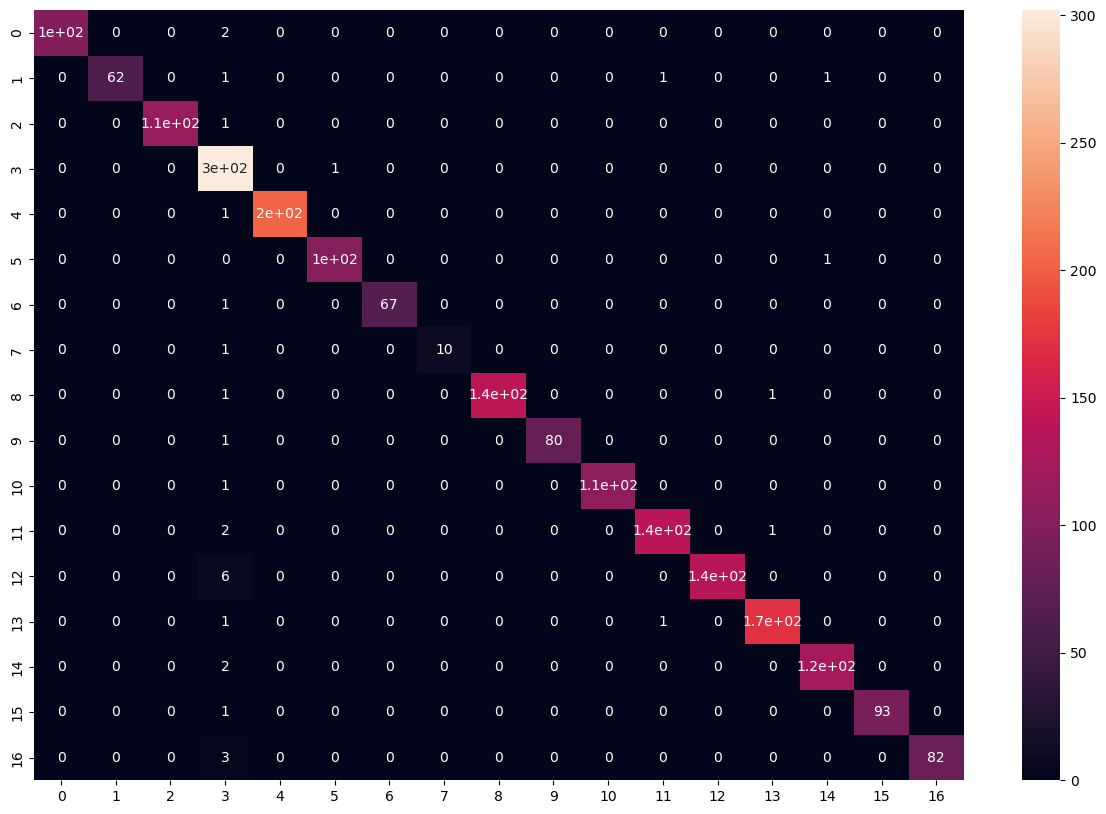

In [13]:
# import re
# import seaborn as sns
# import matplotlib.pyplot as plt
# import warnings
warnings.simplefilter("ignore")
plt.figure(figsize=(15,10))
sns.heatmap(cm, annot = True)
plt.show()

In [14]:
def predict(text):
     x = cv.transform([text]).toarray() # converting text to bag of words model (Vector)
     lang = model.predict(x) # predicting the language
     lang = le.inverse_transform(lang) # finding the language corresponding the the predicted value
     print("The langauge is in",lang[0]) # printing the language


In [15]:
# Arabic
predict("مرحبا كيف حالك؟")

The langauge is in Arabic


In [16]:
# Danish
predict("undskyld at genere dig.")

The langauge is in Danish


In [17]:
# Dutch
predict("Hallo hoe gaat het?؟")

The langauge is in Dutch


In [18]:
# English
predict("Hi, how are you?")

The langauge is in English


In [19]:
# French
predict("Salut comment ça va?")

The langauge is in French


In [20]:
# German
predict("Hi, wie geht es dir?")

The langauge is in German


In [21]:
# Greek
predict("Γεια πως εισαι?")

The langauge is in Greek


In [22]:
# Hindi
predict("नमस्ते, आप कैसे हैं?")

The langauge is in Hindi


In [23]:
# Italian
predict("Ciao, come stai?")

The langauge is in Italian


In [24]:
# Kannada
predict("ಒಂದು ಕ್ಷಣ ನನ್ನೊಂದಿಗೆ ಸಹಿಸಿಕೊಳ್ಳಿ.")

The langauge is in Kannada


In [25]:
# Malayalam
predict("ഹായ്, സുഖമാണോ?")

The langauge is in Malayalam


In [26]:
# Portugeese
predict("Oi como você está?")

The langauge is in Portugeese


In [27]:
# Russian
predict("Привет, как ты?")

The langauge is in Russian


In [28]:
# Spanish
predict("Hola, cómo estás?؟")

The langauge is in Spanish


In [29]:
# Sweedish
predict("Hej hur mår du?")

The langauge is in Sweedish


In [30]:
# Turkish
predict("Merhaba nasılsın?")

The langauge is in Turkish


In [31]:
predict("आप कैसे हैं")

The langauge is in Hindi


In [32]:
predict("How are you?")

The langauge is in English
